# Correct-answer ROC AUC dynamics

This notebook tracks how well the student's single-token answer entropy separates correct from incorrect MMLU answers over training. A correct answer is the positive class, and negative entropy is used as the score so that lower entropy means greater estimated likelihood of correctness.

The comparison includes the random baseline and four entropy-based strategies that re-estimate complexity every epoch: `random`, `entropy_gain`, `entropy_gain_proportional`, `student_entropy`, and `student_entropy_proportional`. One-shot runs are excluded because they cannot provide entropy ROC AUC dynamics.

Two complexity scores are analyzed for every training strategy: student entropy and entropy gain. The experiment constructs proxy teacher entropy by averaging the normalized Llama 70B and Qwen 72B entropies; the sampler then defines entropy gain as `max(student_entropy - teacher_entropy, 0)`. Unsuffixed run directories use seed 42; matching `_seedNN` directories are included as replicas. Curves show the across-seed mean and, when at least two seeds are available, a 95% Student-t confidence interval.

In [1]:
from pathlib import Path
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import t as student_t
from sklearn.metrics import roc_auc_score

for directory in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    source_dir = directory / "src"
    if (source_dir / "core").is_dir():
        sys.path.insert(0, str(source_dir))
        break
else:
    raise FileNotFoundError("Could not find the repository's src/core directory")

from core.utils.graph_style import set_style

set_style()

ARTIFACT_GROUP = "distillation_by_metrics/mmlu"
EXPERIMENTS = (
    "random",
    "entropy_gain",
    "entropy_gain_proportional",
    "student_entropy",
    "student_entropy_proportional",
)
SCORE_COLUMN = "entropy_value"
RANDOM_SELECTION_COLUMN = "random_value"
TEACHER_ENTROPY_COLUMN = "teacher_entropy"
CORRECTNESS_COLUMN = "estimation_phase_answer_correctness"
EXPECTED_EPOCHS = tuple(range(100))
TOP_K_SUBSETS = (1024, 2048)
BASE_SEED = 42
CONFIDENCE_LEVEL = 0.95

EXPERIMENT_LABELS = {
    "random": "Random",
    "entropy_gain": "Entropy gain",
    "entropy_gain_proportional": "Entropy gain proportional",
    "student_entropy": "Student entropy",
    "student_entropy_proportional": "Student entropy proportional",
}
RUN_DIRECTORY_SUFFIXES = {"student_entropy_proportional": "_shuffle"}
MODEL_LABELS = {
    "llama_3b_head_truncated8192": "Llama 3B",
    "phi4_mini_head_truncated8192": "Phi-4 Mini",
    "qwen_3b_head_truncated8192": "Qwen 3B",
}

In [2]:
def find_artifacts_dir(start: Path | None = None) -> Path:
    """Walk upward from the current directory until artifacts/ is found."""
    start = (start or Path.cwd()).resolve()
    for directory in (start, *start.parents):
        candidate = directory / "artifacts"
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError(f"Could not find artifacts/ above {start}")


def discover_model_runs(experiment_dir: Path, model: str) -> list[tuple[Path, int]]:
    """Return the seed-42 base run and exact seed replicas for one model."""
    run_name = model + RUN_DIRECTORY_SUFFIXES.get(experiment_dir.name, "")
    base_run = experiment_dir / run_name
    if not base_run.is_dir():
        raise FileNotFoundError(f"Missing base run directory: {base_run}")

    seed_pattern = re.compile(rf"^{re.escape(run_name)}_seed(?P<seed>\d+)$")
    runs = [(base_run, BASE_SEED)]
    for candidate in sorted(experiment_dir.iterdir()):
        match = seed_pattern.fullmatch(candidate.name)
        if candidate.is_dir() and match:
            runs.append((candidate, int(match.group("seed"))))

    seeds = [seed for _, seed in runs]
    if len(seeds) != len(set(seeds)):
        raise ValueError(f"Duplicate seeds for {experiment_dir.name}/{model}: {seeds}")
    return runs


def load_roc_auc_dynamics(group_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame, list[str]]:
    """Load selected models, their seed replicas, and the configured epochs."""
    records = []
    subset_records = []
    skipped = []

    for experiment in EXPERIMENTS:
        experiment_dir = group_dir / experiment
        if not experiment_dir.is_dir():
            raise FileNotFoundError(f"Missing experiment directory: {experiment_dir}")
        required_columns = [CORRECTNESS_COLUMN, SCORE_COLUMN, TEACHER_ENTROPY_COLUMN]
        if experiment == "random":
            required_columns.append(RANDOM_SELECTION_COLUMN)

        for model in MODEL_LABELS:
            for run_dir, seed in discover_model_runs(experiment_dir, model):
                for epoch in EXPECTED_EPOCHS:
                    parquet_paths = sorted(
                        (run_dir / "resampling_trainer_data" / str(epoch) / "complexity_estimation").glob(
                            "*.parquet"
                        )
                    )
                    if len(parquet_paths) != 1:
                        raise FileNotFoundError(
                            f"Expected one parquet for {experiment}/{run_dir.name}/epoch {epoch}; "
                            f"found {len(parquet_paths)}"
                        )
                    parquet_path = parquet_paths[0]
                    epoch_df = pd.read_parquet(
                        parquet_path,
                        columns=required_columns,
                    ).dropna(subset=required_columns)

                    if epoch_df.empty:
                        skipped.append(f"{experiment}/{run_dir.name}/epoch {epoch}: no valid rows")
                        continue

                    answer_correct = epoch_df[CORRECTNESS_COLUMN].astype(bool).astype(int)
                    correctness_score = -epoch_df[SCORE_COLUMN]
                    entropy_gain = (epoch_df[SCORE_COLUMN] - epoch_df[TEACHER_ENTROPY_COLUMN]).clip(lower=0)
                    if answer_correct.nunique() != 2:
                        skipped.append(f"{experiment}/{run_dir.name}/epoch {epoch}: target has one class")
                        continue

                    records.append(
                        {
                            "experiment": experiment,
                            "model": model,
                            "run": run_dir.name,
                            "seed": seed,
                            "epoch": epoch,
                            "roc_auc": roc_auc_score(answer_correct, correctness_score),
                            "entropy_gain_roc_auc": roc_auc_score(answer_correct, -entropy_gain),
                            "num_valid": len(epoch_df),
                            "accuracy": answer_correct.mean(),
                            "target_classes": answer_correct.nunique(),
                        }
                    )

                    # Match each strategy's top-K selection score while continuing to evaluate
                    # correctness with student-entropy and entropy-gain ROC AUC.
                    if experiment == "random":
                        selection_score = epoch_df[RANDOM_SELECTION_COLUMN]
                    elif experiment in ("student_entropy", "student_entropy_proportional"):
                        selection_score = epoch_df[SCORE_COLUMN]
                    else:
                        selection_score = entropy_gain
                    ranked_df = epoch_df.assign(
                        answer_correct=answer_correct,
                        entropy_gain=entropy_gain,
                        selection_score=selection_score,
                    ).sort_values("selection_score", ascending=False, kind="stable")
                    for top_k in TOP_K_SUBSETS:
                        selected = ranked_df.head(top_k)
                        if selected["answer_correct"].nunique() != 2:
                            skipped.append(f"{experiment}/{run_dir.name}/epoch {epoch}/top {top_k}: target has one class")
                            continue
                        subset_records.append(
                            {
                                "experiment": experiment,
                                "model": model,
                                "run": run_dir.name,
                                "seed": seed,
                                "epoch": epoch,
                                "subset_size": top_k,
                                "num_selected": len(selected),
                                "roc_auc": roc_auc_score(selected["answer_correct"], -selected[SCORE_COLUMN]),
                                "entropy_gain_roc_auc": roc_auc_score(
                                    selected["answer_correct"], -selected["entropy_gain"]
                                ),
                                "target_classes": selected["answer_correct"].nunique(),
                            }
                        )

    all_rows = pd.DataFrame.from_records(records).sort_values(
        ["model", "experiment", "seed", "epoch"]
    ).reset_index(drop=True)
    top_rows = (
        pd.DataFrame.from_records(subset_records)
        .sort_values(["subset_size", "model", "experiment", "seed", "epoch"])
        .reset_index(drop=True)
    )
    return all_rows, top_rows, skipped


def aggregate_seed_metrics(rows: pd.DataFrame, group_columns: list[str]) -> pd.DataFrame:
    """Calculate across-seed means and 95% Student-t confidence intervals."""
    aggregations = {"num_seeds": ("seed", "nunique")}
    for metric in ("roc_auc", "entropy_gain_roc_auc"):
        aggregations[metric] = (metric, "mean")
        aggregations[f"{metric}_std"] = (metric, "std")
    for column in ("num_valid", "num_selected", "accuracy"):
        if column in rows:
            aggregations[column] = (column, "mean")

    summary = rows.groupby(group_columns, as_index=False).agg(**aggregations)
    replicated = summary["num_seeds"].gt(1)
    critical_values = student_t.ppf(
        1 - (1 - CONFIDENCE_LEVEL) / 2,
        summary.loc[replicated, "num_seeds"] - 1,
    )
    for metric in ("roc_auc", "entropy_gain_roc_auc"):
        half_width = critical_values * (
            summary.loc[replicated, f"{metric}_std"]
            / np.sqrt(summary.loc[replicated, "num_seeds"])
        )
        summary[f"{metric}_ci_low"] = np.nan
        summary[f"{metric}_ci_high"] = np.nan
        summary.loc[replicated, f"{metric}_ci_low"] = (
            summary.loc[replicated, metric] - half_width
        ).clip(lower=0)
        summary.loc[replicated, f"{metric}_ci_high"] = (
            summary.loc[replicated, metric] + half_width
        ).clip(upper=1)
    return summary.sort_values(group_columns).reset_index(drop=True)


ARTIFACTS_DIR = find_artifacts_dir()
GROUP_DIR = ARTIFACTS_DIR / ARTIFACT_GROUP
seed_roc_auc_by_epoch, seed_subset_roc_auc_by_epoch, skipped_epochs = load_roc_auc_dynamics(GROUP_DIR)
roc_auc_by_epoch = aggregate_seed_metrics(
    seed_roc_auc_by_epoch, ["model", "experiment", "epoch"]
)
subset_roc_auc_by_epoch = aggregate_seed_metrics(
    seed_subset_roc_auc_by_epoch, ["subset_size", "model", "experiment", "epoch"]
)
print(f"Loaded {len(seed_roc_auc_by_epoch):,} seed-epoch metrics from {GROUP_DIR}")
print(f"Calculated {len(seed_subset_roc_auc_by_epoch):,} seed/top-subset metrics")
print(f"Aggregated to {len(roc_auc_by_epoch):,} epoch means and {len(subset_roc_auc_by_epoch):,} top-subset means")
if skipped_epochs:
    print(f"Skipped {len(skipped_epochs)} invalid epoch(s):")
    print("\n".join(skipped_epochs))

Loaded 2,600 seed-epoch metrics from /Users/aigoncharov/dev/sktech/recursive_caft/artifacts/distillation_by_metrics/mmlu
Calculated 5,200 seed/top-subset metrics
Aggregated to 1,500 epoch means and 3,000 top-subset means


In [3]:
models = sorted(seed_roc_auc_by_epoch["model"].unique())
expected_runs = {(experiment, model) for experiment in EXPERIMENTS for model in MODEL_LABELS}
observed_runs = set(seed_roc_auc_by_epoch[["experiment", "model"]].itertuples(index=False, name=None))

assert not skipped_epochs, "Every selected epoch should have usable two-class data"
assert set(models) == set(MODEL_LABELS), f"Unexpected models: {models}"
assert observed_runs == expected_runs, f"Unexpected run set: {observed_runs}"
assert pd.api.types.is_integer_dtype(seed_roc_auc_by_epoch["epoch"])
assert seed_roc_auc_by_epoch["roc_auc"].between(0, 1).all()
assert seed_roc_auc_by_epoch["entropy_gain_roc_auc"].between(0, 1).all()
assert seed_roc_auc_by_epoch["num_valid"].gt(0).all()
assert seed_roc_auc_by_epoch["target_classes"].eq(2).all()
assert not seed_roc_auc_by_epoch.duplicated(["experiment", "model", "seed", "epoch"]).any()
for _, run in seed_roc_auc_by_epoch.groupby(["experiment", "model", "seed"]):
    assert set(run["epoch"]) == set(EXPECTED_EPOCHS)

seed_runs = seed_roc_auc_by_epoch[["experiment", "model", "seed"]].drop_duplicates()
expected_seed_rows = len(seed_runs) * len(EXPECTED_EPOCHS)
assert len(seed_roc_auc_by_epoch) == expected_seed_rows
assert len(seed_subset_roc_auc_by_epoch) == expected_seed_rows * len(TOP_K_SUBSETS)
assert set(seed_subset_roc_auc_by_epoch["subset_size"]) == set(TOP_K_SUBSETS)
assert seed_subset_roc_auc_by_epoch["num_selected"].eq(seed_subset_roc_auc_by_epoch["subset_size"]).all()
assert seed_subset_roc_auc_by_epoch["roc_auc"].between(0, 1).all()
assert seed_subset_roc_auc_by_epoch["entropy_gain_roc_auc"].between(0, 1).all()
assert seed_subset_roc_auc_by_epoch["target_classes"].eq(2).all()
for _, run in seed_subset_roc_auc_by_epoch.groupby(["subset_size", "experiment", "model", "seed"]):
    assert set(run["epoch"]) == set(EXPECTED_EPOCHS)

replicated = roc_auc_by_epoch["num_seeds"].gt(1)
for metric in ("roc_auc", "entropy_gain_roc_auc"):
    assert roc_auc_by_epoch.loc[replicated, [f"{metric}_ci_low", f"{metric}_ci_high"]].notna().all().all()
    assert roc_auc_by_epoch.loc[~replicated, [f"{metric}_ci_low", f"{metric}_ci_high"]].isna().all().all()

seed_coverage = (
    seed_runs.groupby(["model", "experiment"])["seed"]
    .agg(lambda seeds: ", ".join(map(str, sorted(seeds))))
    .rename("Seeds")
    .reset_index()
)
seed_coverage["model"] = seed_coverage["model"].map(MODEL_LABELS)
seed_coverage["experiment"] = seed_coverage["experiment"].map(EXPERIMENT_LABELS)
display(seed_coverage.rename(columns={"model": "Model", "experiment": "Strategy"}))
print(
    f"Validated {len(seed_runs)} seeded runs across {len(MODEL_LABELS)} models × "
    f"{len(EXPERIMENTS)} strategies × {len(EXPECTED_EPOCHS)} complete epochs."
)
print("Validated exact top-1,024 and top-2,048 subsets for every seed and epoch.")

,Model,Strategy,Seeds
0,Llama 3B,Entropy gain,42
1,Llama 3B,Entropy gain proportional,42
2,Llama 3B,Random,"42, 43, 44"
3,Llama 3B,Student entropy,42
4,Llama 3B,Student entropy proportional,"42, 43, 44"
5,Phi-4 Mini,Entropy gain,42
6,Phi-4 Mini,Entropy gain proportional,42
7,Phi-4 Mini,Random,"42, 43, 44"
8,Phi-4 Mini,Student entropy,42
9,Phi-4 Mini,Student entropy proportional,"42, 43, 44"


Validated 26 seeded runs across 3 models × 5 strategies × 100 complete epochs.
Validated exact top-1,024 and top-2,048 subsets for every seed and epoch.


In [4]:
summary = (
    roc_auc_by_epoch.sort_values("epoch")
    .groupby(["model", "experiment"], as_index=False)
    .agg(
        initial_roc_auc=("roc_auc", "first"),
        initial_ci_low=("roc_auc_ci_low", "first"),
        initial_ci_high=("roc_auc_ci_high", "first"),
        final_roc_auc=("roc_auc", "last"),
        final_ci_low=("roc_auc_ci_low", "last"),
        final_ci_high=("roc_auc_ci_high", "last"),
        peak_roc_auc=("roc_auc", "max"),
        num_seeds=("num_seeds", "max"),
        min_valid_samples=("num_valid", "min"),
    )
)
summary["model"] = summary["model"].map(MODEL_LABELS)
summary["experiment"] = summary["experiment"].map(EXPERIMENT_LABELS)
display(
    summary.rename(columns={"model": "Model", "experiment": "Strategy"}).style.format(
        {
            "initial_roc_auc": "{:.3f}",
            "initial_ci_low": "{:.3f}",
            "initial_ci_high": "{:.3f}",
            "final_roc_auc": "{:.3f}",
            "final_ci_low": "{:.3f}",
            "final_ci_high": "{:.3f}",
            "peak_roc_auc": "{:.3f}",
            "min_valid_samples": "{:,.0f}",
        }
    )
)

,Model,Strategy,initial_roc_auc,initial_ci_low,initial_ci_high,final_roc_auc,final_ci_low,final_ci_high,peak_roc_auc,num_seeds,min_valid_samples
0,Llama 3B,Entropy gain,0.708,nan,nan,0.663,nan,nan,0.785,1,"9,567"
1,Llama 3B,Entropy gain proportional,0.708,nan,nan,0.846,nan,nan,0.868,1,"9,610"
2,Llama 3B,Random,0.707,0.702,0.712,0.918,0.903,0.933,0.919,3,"9,625"
3,Llama 3B,Student entropy,0.709,nan,nan,0.473,nan,nan,0.731,1,"9,623"
4,Llama 3B,Student entropy proportional,0.706,0.704,0.709,0.878,0.849,0.907,0.882,3,"9,624"
5,Phi-4 Mini,Entropy gain,0.732,nan,nan,0.658,nan,nan,0.796,1,"9,626"
6,Phi-4 Mini,Entropy gain proportional,0.735,nan,nan,0.828,nan,nan,0.871,1,"9,625"
7,Phi-4 Mini,Random,0.735,0.735,0.735,0.927,0.917,0.937,0.929,3,"9,626"
8,Phi-4 Mini,Student entropy,0.732,nan,nan,0.483,nan,nan,0.763,1,"9,626"
9,Phi-4 Mini,Student entropy proportional,0.735,0.735,0.735,0.821,0.771,0.871,0.866,3,"9,626"


In [5]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

SCORE_LINESTYLES = {
    "roc_auc": ("Student entropy", "-"),
    "entropy_gain_roc_auc": ("Entropy gain", "--"),
}
STRATEGY_COLORS = {experiment: plt.get_cmap("tab10")(i) for i, experiment in enumerate(EXPERIMENTS)}

## Entropy-gain proxy and combined comparison

The experiment builds `teacher_entropy` as the row-wise average of normalized Llama 70B and Qwen 72B single-token entropies. Matching `EntropyGainSampler._score_row`, the proxy is calculated without any additional normalization:

```python
entropy_gain = max(entropy_value - teacher_entropy, 0)
```

Correctness is the positive class, so the ROC score is `-entropy_gain`: a smaller gap between student and teacher entropy predicts a correct student answer. The proportional samplers' random race keys are deliberately excluded because they control sampling, not the underlying student-entropy or entropy-gain proxies. The combined plot uses line style for the complexity score and color for the training strategy.

In [6]:
entropy_gain_summary = (
    roc_auc_by_epoch.sort_values("epoch")
    .groupby(["model", "experiment"], as_index=False)
    .agg(
        initial_roc_auc=("entropy_gain_roc_auc", "first"),
        initial_ci_low=("entropy_gain_roc_auc_ci_low", "first"),
        initial_ci_high=("entropy_gain_roc_auc_ci_high", "first"),
        final_roc_auc=("entropy_gain_roc_auc", "last"),
        final_ci_low=("entropy_gain_roc_auc_ci_low", "last"),
        final_ci_high=("entropy_gain_roc_auc_ci_high", "last"),
        peak_roc_auc=("entropy_gain_roc_auc", "max"),
        num_seeds=("num_seeds", "max"),
        min_valid_samples=("num_valid", "min"),
    )
)
entropy_gain_summary["model"] = entropy_gain_summary["model"].map(MODEL_LABELS)
entropy_gain_summary["experiment"] = entropy_gain_summary["experiment"].map(EXPERIMENT_LABELS)
display(
    entropy_gain_summary.rename(columns={"model": "Model", "experiment": "Strategy"}).style.format(
        {
            "initial_roc_auc": "{:.3f}",
            "initial_ci_low": "{:.3f}",
            "initial_ci_high": "{:.3f}",
            "final_roc_auc": "{:.3f}",
            "final_ci_low": "{:.3f}",
            "final_ci_high": "{:.3f}",
            "peak_roc_auc": "{:.3f}",
            "min_valid_samples": "{:,.0f}",
        }
    )
)

,Model,Strategy,initial_roc_auc,initial_ci_low,initial_ci_high,final_roc_auc,final_ci_low,final_ci_high,peak_roc_auc,num_seeds,min_valid_samples
0,Llama 3B,Entropy gain,0.666,nan,nan,0.378,nan,nan,0.700,1,"9,567"
1,Llama 3B,Entropy gain proportional,0.667,nan,nan,0.709,nan,nan,0.817,1,"9,610"
2,Llama 3B,Random,0.666,0.663,0.669,0.894,0.889,0.899,0.894,3,"9,625"
3,Llama 3B,Student entropy,0.668,nan,nan,0.540,nan,nan,0.708,1,"9,623"
4,Llama 3B,Student entropy proportional,0.665,0.662,0.668,0.817,0.780,0.854,0.845,3,"9,624"
5,Phi-4 Mini,Entropy gain,0.701,nan,nan,0.329,nan,nan,0.720,1,"9,626"
6,Phi-4 Mini,Entropy gain proportional,0.703,nan,nan,0.597,nan,nan,0.825,1,"9,625"
7,Phi-4 Mini,Random,0.703,0.703,0.703,0.877,0.858,0.896,0.890,3,"9,626"
8,Phi-4 Mini,Student entropy,0.700,nan,nan,0.507,nan,nan,0.731,1,"9,626"
9,Phi-4 Mini,Student entropy proportional,0.703,0.703,0.703,0.758,0.733,0.783,0.830,3,"9,626"


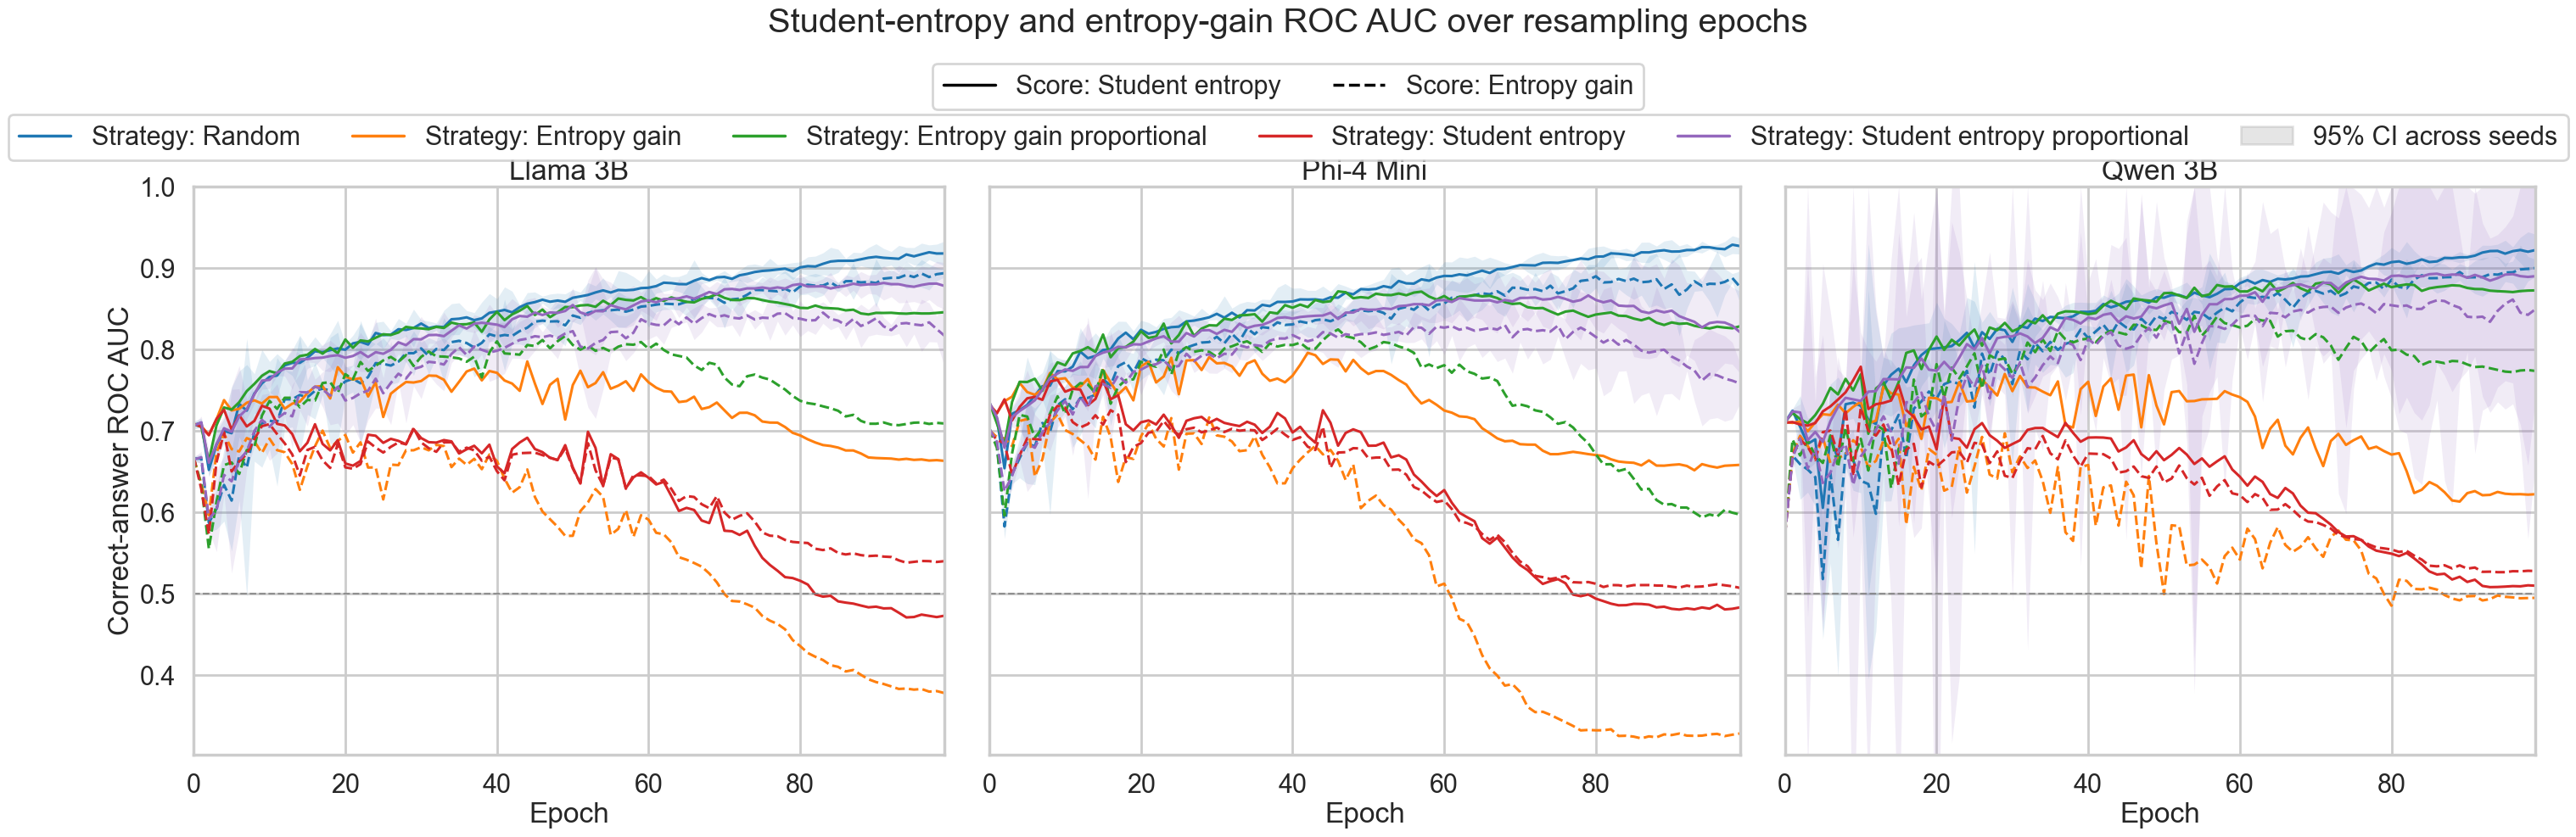

In [7]:
fig, axes = plt.subplots(1, len(models), figsize=(30, 10), sharex=True, sharey=True)

for ax, model in zip(axes, models, strict=True):
    model_data = roc_auc_by_epoch[roc_auc_by_epoch["model"] == model]
    for experiment in EXPERIMENTS:
        curve = model_data[model_data["experiment"] == experiment]
        for score_column, (_, linestyle) in SCORE_LINESTYLES.items():
            ax.plot(
                curve["epoch"],
                curve[score_column],
                color=STRATEGY_COLORS[experiment],
                linestyle=linestyle,
                linewidth=2.2,
            )
            if curve[f"{score_column}_ci_low"].notna().any():
                ax.fill_between(
                    curve["epoch"],
                    curve[f"{score_column}_ci_low"],
                    curve[f"{score_column}_ci_high"],
                    color=STRATEGY_COLORS[experiment],
                    alpha=0.12,
                    linewidth=0,
                )
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.5, alpha=0.8)
    ax.set_title(MODEL_LABELS[model])
    ax.set_xlabel("Epoch")
    ax.set_xlim(min(EXPECTED_EPOCHS), max(EXPECTED_EPOCHS))

axes[0].set_ylabel("Correct-answer ROC AUC")
all_auc_values = roc_auc_by_epoch[["roc_auc", "entropy_gain_roc_auc"]]
axes[0].set_ylim(min(0.48, all_auc_values.min().min() - 0.02), 1.0)
score_handles = [
    Line2D(
        [0],
        [0],
        color="black",
        linestyle=linestyle,
        linewidth=2.5,
        label=f"Score: {label}",
    )
    for label, linestyle in SCORE_LINESTYLES.values()
]
strategy_handles = [
    Line2D(
        [0],
        [0],
        color=STRATEGY_COLORS[experiment],
        linestyle="-",
        linewidth=2.5,
        label=f"Strategy: {EXPERIMENT_LABELS[experiment]}",
    )
    for experiment in EXPERIMENTS
]
confidence_handle = Patch(color="gray", alpha=0.2, label="95% CI across seeds")


def add_stacked_legend(fig):
    fig.legend(
        handles=score_handles,
        loc="upper center",
        ncol=len(score_handles),
        bbox_to_anchor=(0.5, 0.94),
    )
    fig.legend(
        handles=strategy_handles + [confidence_handle],
        loc="upper center",
        ncol=len(strategy_handles) + 1,
        bbox_to_anchor=(0.5, 0.88),
    )


add_stacked_legend(fig)
fig.suptitle("Student-entropy and entropy-gain ROC AUC over resampling epochs", y=0.99)
fig.subplots_adjust(left=0.07, right=0.99, bottom=0.11, top=0.78, wspace=0.06)

assert sum(len(ax.lines) - 1 for ax in axes) == len(models) * len(EXPERIMENTS) * len(SCORE_LINESTYLES)
plt.show()

## ROC AUC within top-complexity subsets

The following figures restrict each epoch to exactly the top 1,024 or top 2,048 rows. `random` runs are ranked by `random_value`, both student-entropy runs by student entropy, and both entropy-gain runs by clipped entropy gain. The selection score controls only subset membership: ROC AUC is still recomputed from student entropy and entropy gain for every strategy. Lines are across-seed means and shaded regions are 95% Student-t confidence intervals where replicas exist. The proportional samplers' stochastic race keys and the experiment's separate 256-row single-token mix are not included.

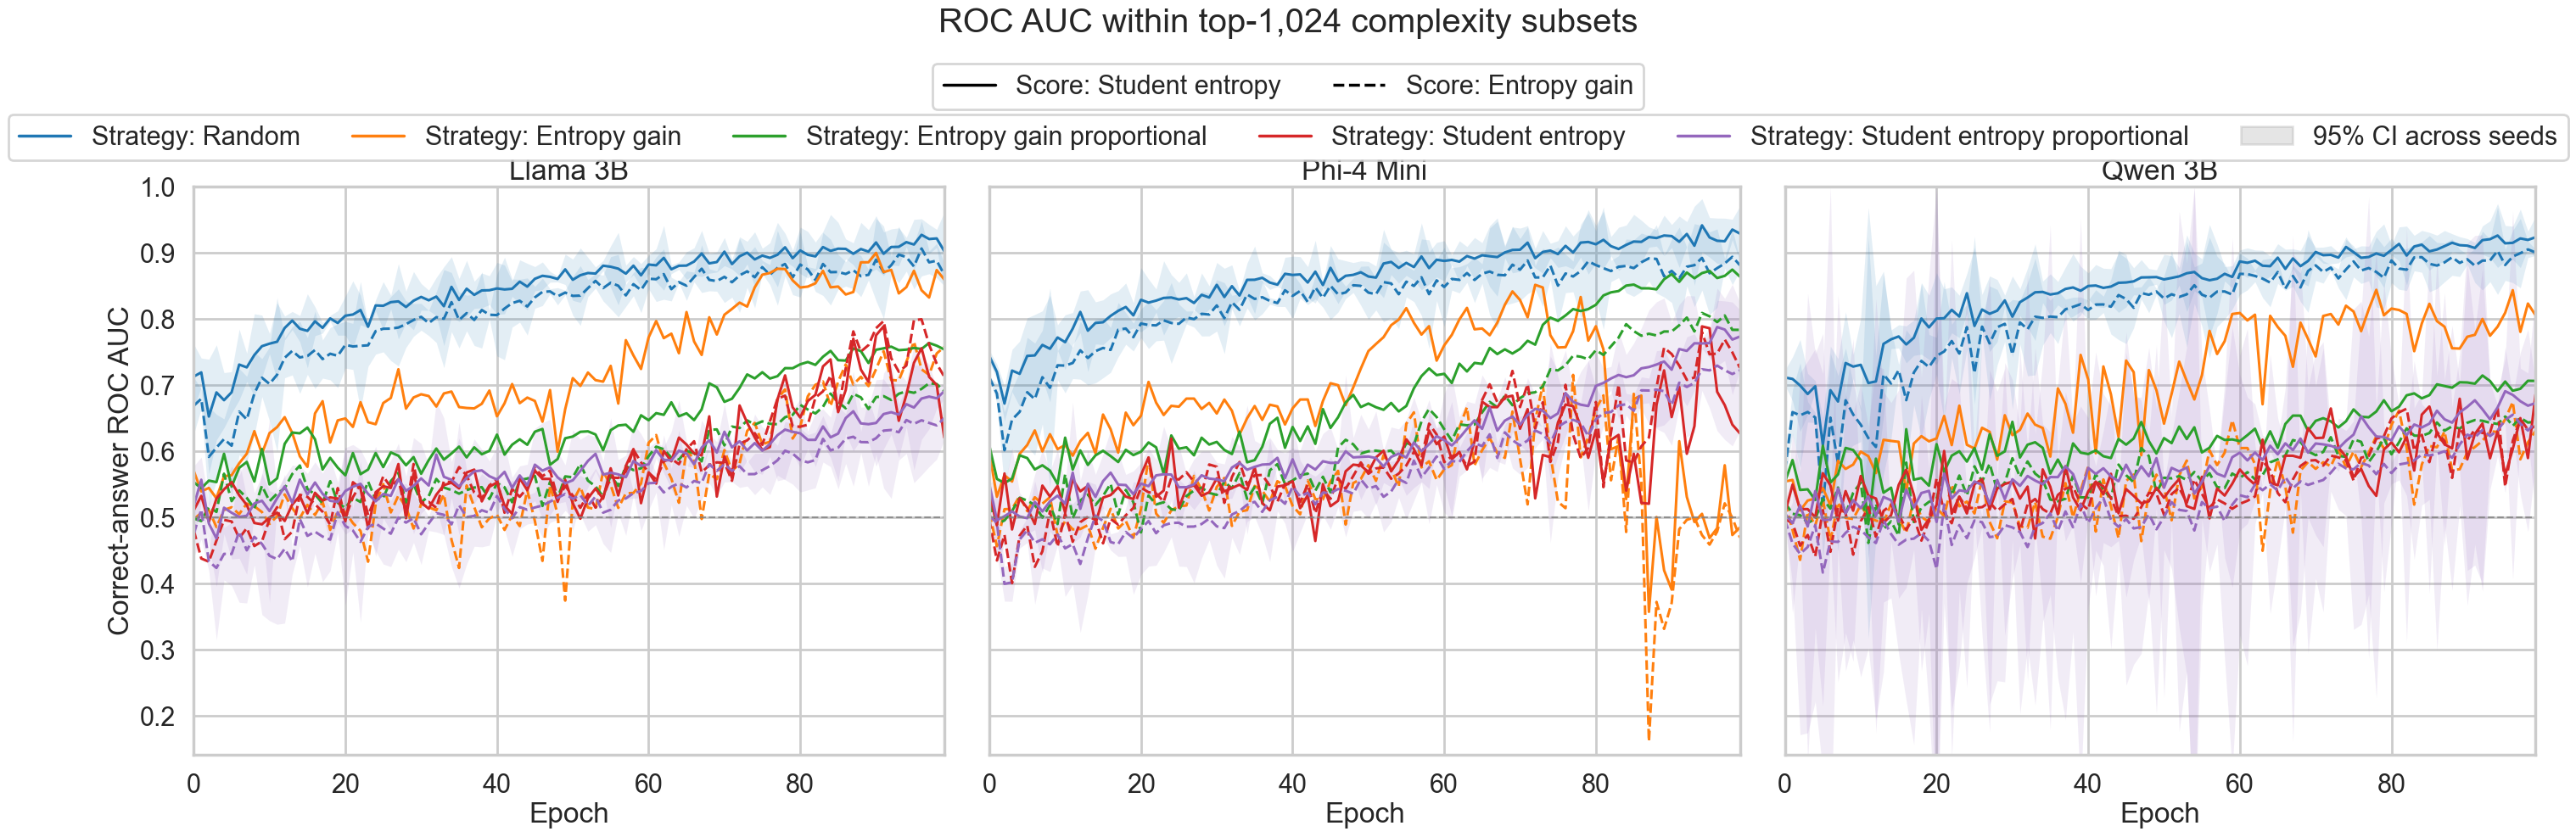

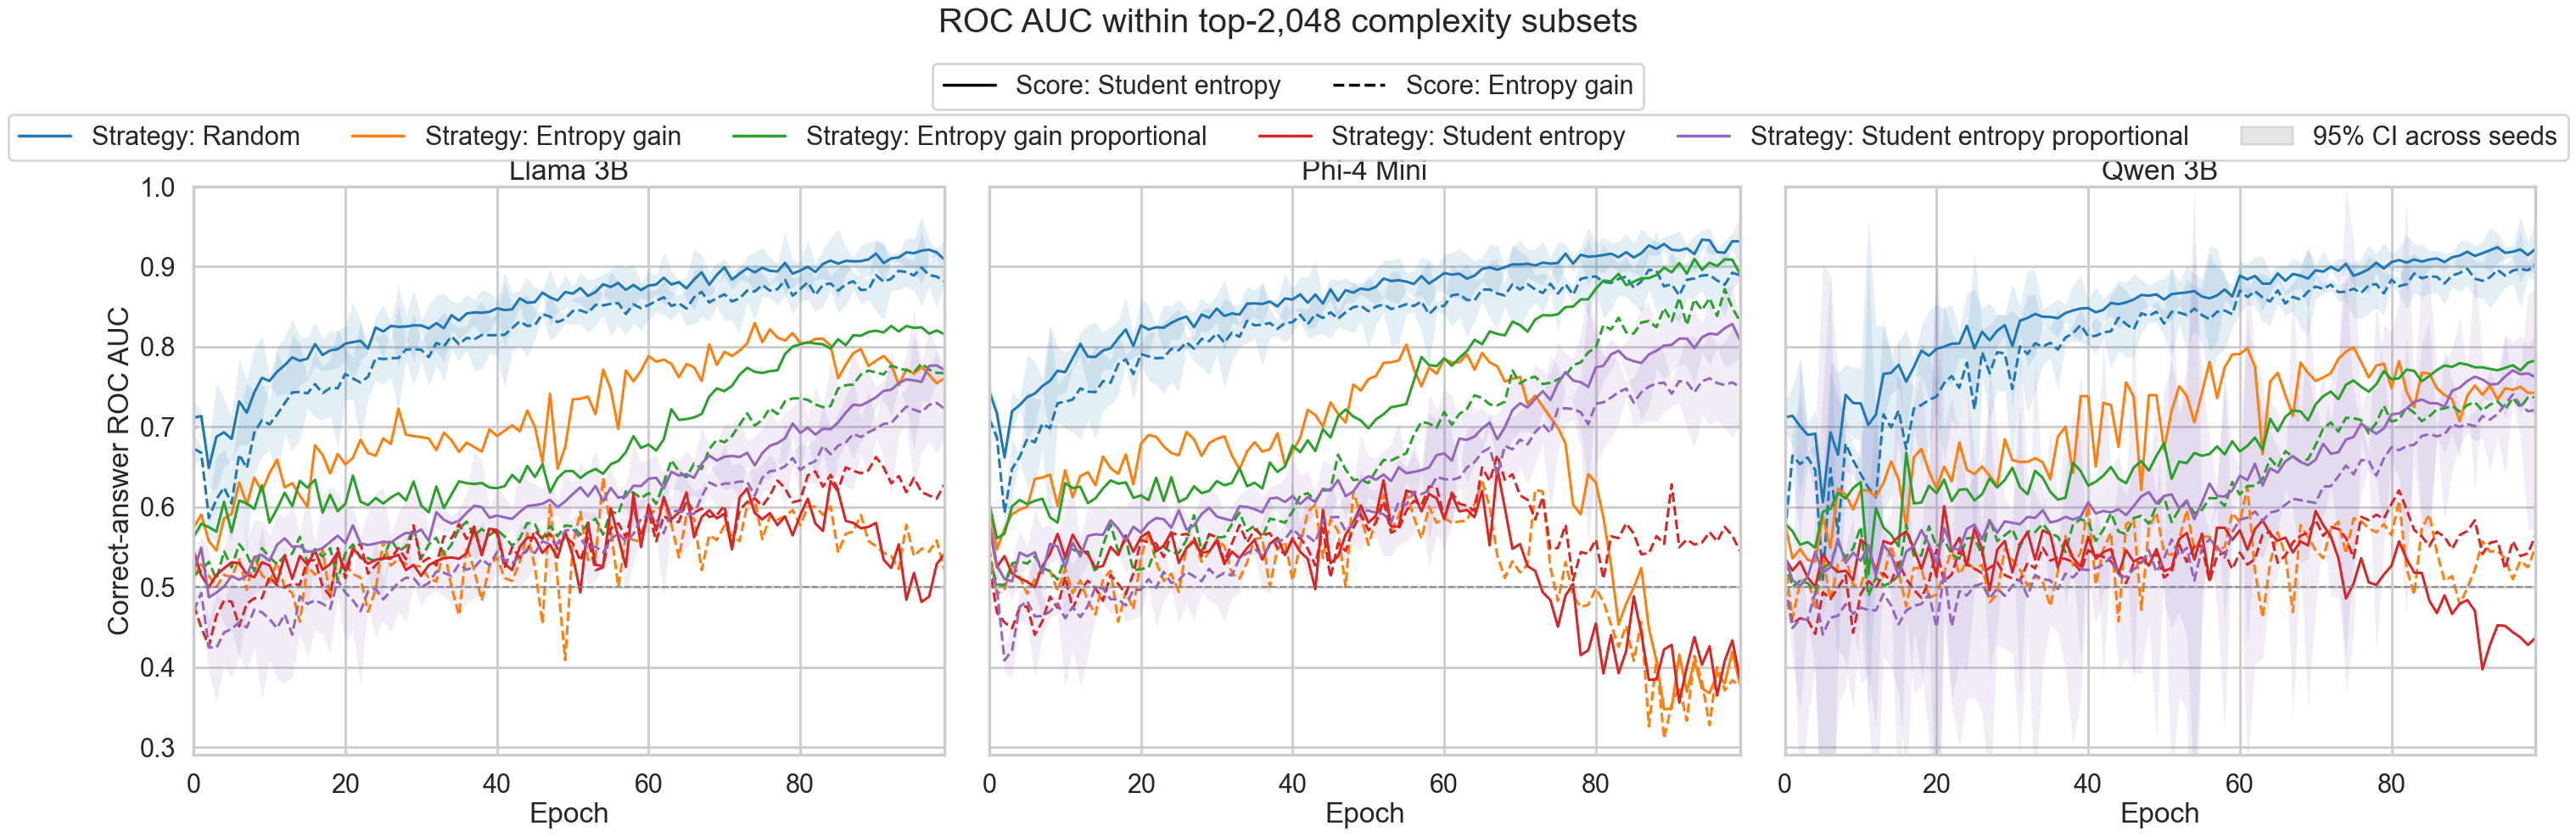

In [8]:
for subset_size in TOP_K_SUBSETS:
    subset_data = subset_roc_auc_by_epoch[subset_roc_auc_by_epoch["subset_size"] == subset_size]
    fig, axes = plt.subplots(1, len(models), figsize=(30, 10), sharex=True, sharey=True)

    for ax, model in zip(axes, models, strict=True):
        model_data = subset_data[subset_data["model"] == model]
        for experiment in EXPERIMENTS:
            curve = model_data[model_data["experiment"] == experiment]
            for score_column, (_, linestyle) in SCORE_LINESTYLES.items():
                ax.plot(
                    curve["epoch"],
                    curve[score_column],
                    color=STRATEGY_COLORS[experiment],
                    linestyle=linestyle,
                    linewidth=2.2,
                )
                if curve[f"{score_column}_ci_low"].notna().any():
                    ax.fill_between(
                        curve["epoch"],
                        curve[f"{score_column}_ci_low"],
                        curve[f"{score_column}_ci_high"],
                        color=STRATEGY_COLORS[experiment],
                        alpha=0.12,
                        linewidth=0,
                    )
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.5, alpha=0.8)
        ax.set_title(MODEL_LABELS[model])
        ax.set_xlabel("Epoch")
        ax.set_xlim(min(EXPECTED_EPOCHS), max(EXPECTED_EPOCHS))

    axes[0].set_ylabel("Correct-answer ROC AUC")
    subset_auc_values = subset_data[["roc_auc", "entropy_gain_roc_auc"]]
    axes[0].set_ylim(min(0.48, subset_auc_values.min().min() - 0.02), 1.0)
    add_stacked_legend(fig)
    fig.suptitle(f"ROC AUC within top-{subset_size:,} complexity subsets", y=0.99)
    fig.subplots_adjust(left=0.07, right=0.99, bottom=0.11, top=0.78, wspace=0.06)

    assert sum(len(ax.lines) - 1 for ax in axes) == len(models) * len(EXPERIMENTS) * len(SCORE_LINESTYLES)
    plt.show()